In [8]:
import pandas as pd
data = pd.read_csv("student.csv")
print(data.head())

FileNotFoundError: [Errno 2] No such file or directory: 'student.csv'

In [ ]:
data = data.drop('student_id',axis=1)

In [ ]:
print(data.head())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score grade  
0         97.9     A  
1         83.9     B  
2        100.0     A  
3        100.0     A  
4         92.0     A  


In [ ]:
print(data.isnull().sum())

weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64


In [ ]:
data['grade'] = data['grade'].map({
    'A' : 3,
    'B' : 2,
    'C' : 1,
    'D' : 0
})

In [ ]:
print(data.head())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score  grade  
0         97.9    3.0  
1         83.9    2.0  
2        100.0    3.0  
3        100.0    3.0  
4         92.0    3.0  


In [ ]:
x = data[['weekly_self_study_hours',
          'attendance_percentage',
          'class_participation',
          'total_score']]
y = data['grade']

In [ ]:
print(data.head())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score  grade  
0         97.9    3.0  
1         83.9    2.0  
2        100.0    3.0  
3        100.0    3.0  
4         92.0    3.0  


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(x)

In [ ]:
print(data.head())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score  grade  
0         97.9    3.0  
1         83.9    2.0  
2        100.0    3.0  
3        100.0    3.0  
4         92.0    3.0  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
mask = y.notna()
x = x[mask]
y = y[mask]

x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)
model =  LogisticRegression()
model.fit(x_train,y_train)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
x_train.isna().sum()

weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
dtype: int64

In [ ]:
y.isna().sum()

np.int64(0)

In [ ]:
print(data.head())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score  grade  
0         97.9    3.0  
1         83.9    2.0  
2        100.0    3.0  
3        100.0    3.0  
4         92.0    3.0  


In [ ]:
y_pred = model.predict(x_test)
print(y_pred)

[0. 3. 3. ... 3. 3. 3.]


In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7843429261420809


In [ ]:
# Example student input
new_student = [[15, 85, 6, 90]]

# Scale input
new_student = scaler.transform(new_student)

# Predict
result = model.predict(new_student)

# Convert number → grade
grade_map = {
    3: 'A',
    2: 'B',
    1: 'C',
    0: 'D'
}

print("Predicted Grade:", grade_map[int(result[0])])

Predicted Grade: B


C:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


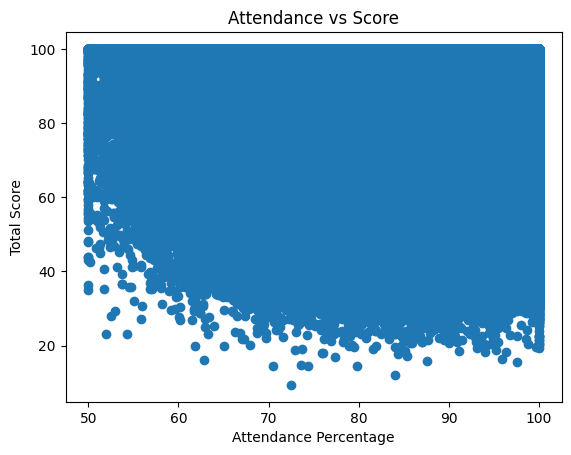

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(data['attendance_percentage'], data['total_score'])
plt.xlabel("Attendance Percentage")
plt.ylabel("Total Score")
plt.title("Attendance vs Score")
plt.show()

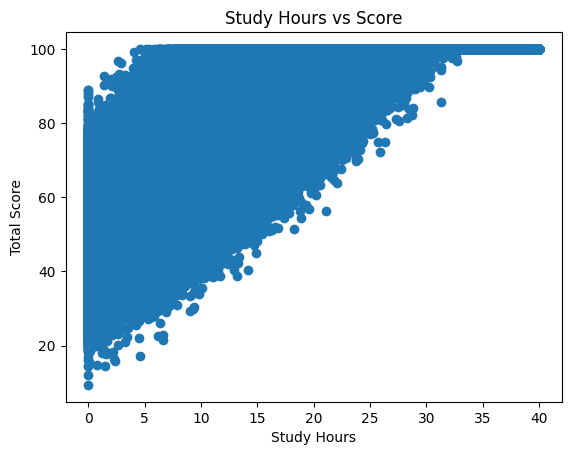

In [ ]:
plt.scatter(data['weekly_self_study_hours'], data['total_score'])
plt.xlabel("Study Hours")
plt.ylabel("Total Score")
plt.title("Study Hours vs Score")
plt.show()

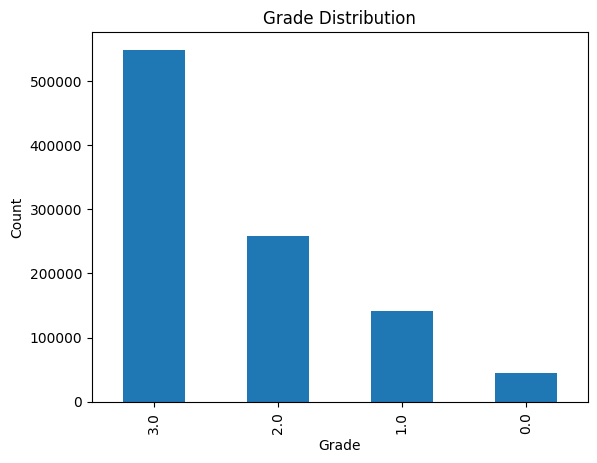

In [ ]:
data['grade'].value_counts().plot(kind='bar')
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

In [10]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd

# Load dataset
df = pd.read_csv("student.csv")

# Check dataset
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'student.csv'